# The Basics of Supply and Demand

In [ ]:
pip install numpy matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import matplotlib.pyplot as plt

## Definitions
- **Microeconomics** : Analysis of the economic behaviour of individual decision-making units in a free market economy
    - Microeconomics discusses:
        - Supply and demand of goods and services
        - Price and production costs of goods and services
        - Objectives (profit, growth, and survival) and competitiveness of business firm
        - Theory of production

- **Macroeconomics** : Analysis of aggregate behaviour at the national and international levels
    - Macroeconomics discusses:
        - Level of growth of consumption and income
        - Level and trends in prices, wages, and investment
        - Government policies and incentives
        - Interactions between businesses, government and society, and between business sectors
- **Finance** : Study of how businesses raise and spend capital
    - Finance discusses:
        - Sources and costs of funds
        - Capital markets
        - Dividend policies
        - Capital budgeting

## Supply & Demand

### Supply Curve
- **Supply Curve** : Relationship between the quantity of a good that producers are willing to sell and the price of the good

$$
Q_s = Q_s(P)
$$

where $Q_s$ is the quantity supplied, and $P$ is the price

Alternative Format:
$$
P = f(Q_s)
$$
since the axes for these graphs are inversed

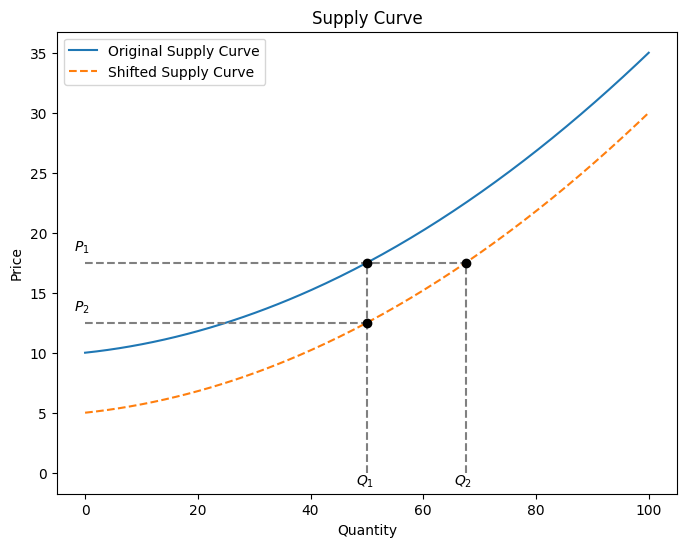

In [75]:
q = np.linspace(0,100,200)

a, b, c = 0.002, 0.05, 10
supply_curve = (a * q**2) + (b * q) + c

shift = 5
supply_curve_shifted = (a * q**2) + (b * q) + (c - shift)

q1 = 50
p1 = np.interp(q1, q, supply_curve)
p2 = np.interp(q1, q, supply_curve_shifted)

c_prime = c-shift-p1

roots = np.roots([a, b, c_prime])

q2 = roots[np.isreal(roots) & (roots > 0)].real[0]

plt.figure(figsize=(8,6))

# Supply curves
plt.plot(q, supply_curve, label="Original Supply Curve")
plt.plot(q, supply_curve_shifted, linestyle="--", label="Shifted Supply Curve")

plt.scatter([q1, q2], [p1, p1], color="black", zorder=5)
plt.scatter(q1, p2, color="black", zorder=5)

plt.text(q1 - 2, -1, "$Q_1$")
plt.text(q2 - 2, -1, "$Q_2$")
plt.text(-2, p1 + 1, "$P_1$")
plt.text(-2, p2 + 1, "$P_2$")

# Dashed guide lines
plt.hlines(p1, xmin=0, xmax=q2, linestyles="dashed", colors="gray")
plt.hlines(p2, xmin=0, xmax=q1, linestyles="dashed", colors="gray")
plt.vlines([q1, q2], ymin=0, ymax=p1, linestyles="dashed", colors="gray")

plt.xlabel("Quantity")
plt.ylabel("Price")
plt.title("Supply Curve")
plt.legend()
plt.show()


The graph above displays how if production costs fall, firms can produce the same quantity for a lesser price, or a larger quantity at the same price.

#### Extra Variables that Affect Supply
- Production costs (PC):
    - wages
    - interest
    - cost of raw materials

When PC _decreases_, output _increases_ -> supply curve shifts to right

**Change in Supply** refers to shift in curve

**Change in Quantity Supplied** refers to movements along the curve

### Demand Curve
- **Demand Curve**: Relationship between the quantity of a good that consumers are willing to buy and the price of the good
$$
Q_D = Q_D(P)
$$
where $Q_D$ is the quantity demanded and $P$ is the price

Alternative Format:
$$
P = f(Q_D)
$$
since the axes for these graphs are inversed

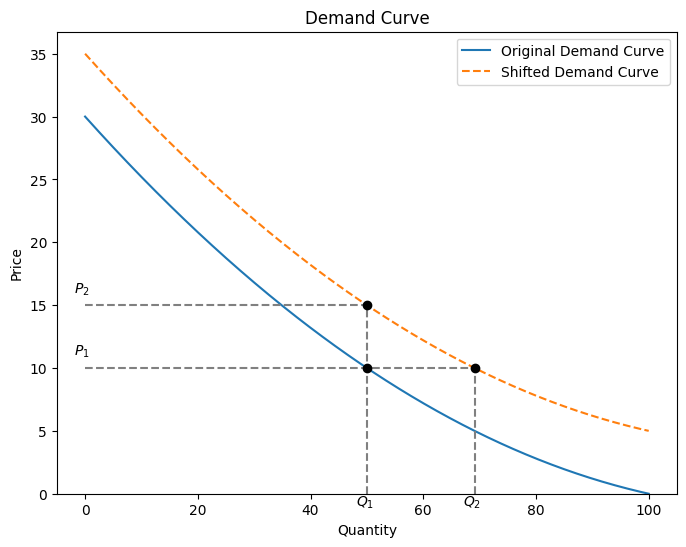

In [74]:
q = np.linspace(0, 100, 400)

a, b, c = 0.002, -0.5, 10
demand_curve = a*q**2 + b*q + c

shift = 5
demand_curve_shifted = a*q**2 + b*q + (c + shift)

min_price = min(demand_curve.min(), demand_curve_shifted.min())
offset = -min_price if min_price < 0 else 0

demand_curve += offset
demand_curve_shifted += offset

q1 = 50
p1 = a*q1**2 + b*q1 + c + offset
p2 = p1 + shift

coeffs = [a, b, (c + shift - (p1 - offset))]
roots = np.roots(coeffs)
real_roots = roots[np.isreal(roots)].real
q2 = real_roots[(real_roots >= 0) & (real_roots <= 100)][0]

plt.figure(figsize=(8, 6))
plt.plot(q, demand_curve, label="Original Demand Curve")
plt.plot(q, demand_curve_shifted, linestyle="--", label="Shifted Demand Curve")

plt.scatter([q1], [p1], color="black", zorder=5)
plt.scatter([q1], [p2], color="black", zorder=5)
plt.scatter([q2], [p1], color="black", zorder=5)

plt.hlines(p1, xmin=0, xmax=q2, linestyles="dashed", colors="gray")
plt.hlines(p2, xmin=0, xmax=q1, linestyles="dashed", colors="gray")
plt.vlines(q1, ymin=0, ymax=p2, linestyles="dashed", colors="gray")
plt.vlines(q2, ymin=0, ymax=p1, linestyles="dashed", colors="gray")

plt.ylim(bottom=0)

plt.text(q1 - 2, -1, "$Q_1$")
plt.text(q2 - 2, -1, "$Q_2$")
plt.text(-2, p1 + 1, "$P_1$")
plt.text(-2, p2 + 1, "$P_2$")

plt.xlabel("Quantity")
plt.ylabel("Price")
plt.title("Demand Curve")
plt.legend()
plt.show()


The graph above displays how the quantity of a good demanded by consumers depends on its price. 

#### Extra Variables that Affect Demand
- Income
- Prices of other goods
- Substitutes
    - Two goods for which the increase in the price of one leads to an increase in the quantity demanded for the other
- Complements
    - Two goods for which the increase in the price of one leads to a decrease in the quantity demanded for the other

A *higher income level* shifts the demand curve to the right



## Market Mechanism

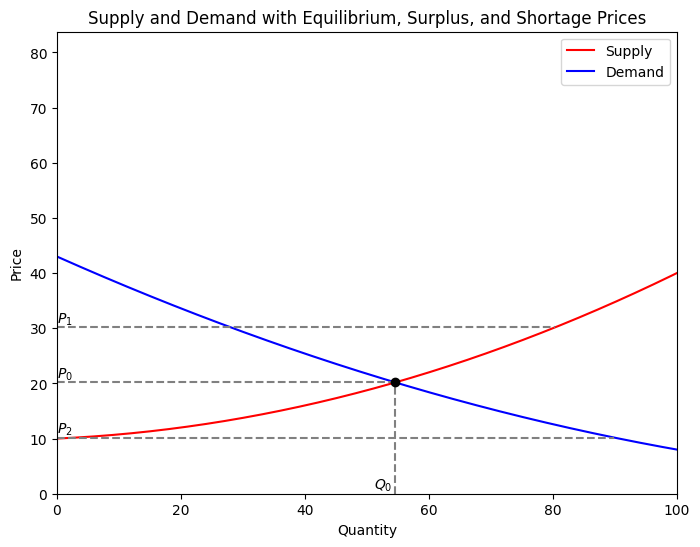

In [104]:

q = np.linspace(0, 150, 400)

a_s, b_s, c_s = 0.0025, 0.05, 10
supply_curve = a_s*q**2 + b_s*q + c_s

a_d, b_d, c_d = 0.0015, -0.5, 43
demand_curve = a_d*q**2 + b_d*q + c_d

A = a_s - a_d
B = b_s - b_d
C = c_s - c_d

if np.isclose(A, 0):
    if np.isclose(B, 0):
        raise ValueError("Supply and demand do not have a unique intersection.")
    q_eq = -C / B
else:
    roots = np.roots([A, B, C])
    candidates = roots[np.isreal(roots)].real
    candidates = candidates[candidates >= 0]
    if candidates.size == 0:
        raise ValueError("No real non-negative intersection.")
    q_eq = candidates.min()

p_eq = a_s*q_eq**2 + b_s*q_eq + c_s

p_surplus = p_eq + 10
p_shortage = p_eq - 10

s_roots = np.roots([a_s, b_s, c_s - p_surplus])
s_candidates = s_roots[np.isreal(s_roots)].real
s_candidates = s_candidates[s_candidates >= 0]
q_supply_at_surplus = s_candidates.min() if s_candidates.size else np.nan

d_roots = np.roots([a_d, b_d, c_d - p_shortage])
d_candidates = d_roots[np.isreal(d_roots)].real
d_candidates = d_candidates[d_candidates >= 0]
q_demand_at_shortage = d_candidates.min() if d_candidates.size else np.nan

plt.figure(figsize=(8, 6))

plt.plot(q, supply_curve, label="Supply", color="red")
plt.plot(q, demand_curve, label="Demand", color="blue")

plt.scatter([q_eq], [p_eq], color="black", zorder=5)
plt.hlines(p_eq, xmin=0, xmax=q_eq, linestyles="dashed", colors="gray")
plt.vlines(q_eq, ymin=0, ymax=p_eq, linestyles="dashed", colors="gray")

plt.text(q_eq - 2, 0, "$Q_0$", ha="center", va="bottom")
plt.text(0, p_eq, "$P_0$", ha="left", va="bottom")

plt.hlines(p_surplus, xmin=0, xmax=q_supply_at_surplus, linestyles="dashed", colors="gray")
plt.hlines(p_shortage, xmin=0, xmax=q_demand_at_shortage, linestyles="dashed", colors="gray")

plt.text(0, p_surplus, "$P_1$", ha="left", va="bottom")
plt.text(0, p_shortage, "$P_2$", ha="left", va="bottom")

plt.xlim(0, 100)
plt.ylim(0, max(supply_curve.max(), demand_curve.max()) + 10)

plt.xlabel("Quantity")
plt.ylabel("Price")
plt.title("Supply and Demand with Equilibrium, Surplus, and Shortage Prices")
plt.legend()
plt.show()


The graph above shows the market clears at Price $P_0$ and quantity $Q_0$. 

At the higher price $P_1$, a surplus develops, leading prices to fall.

At the lower price $P_2$, there is a shortage, so price is bid up.

### Definitions
- **Equilibrium Price**
    - Price that equates quantity supplied to quantity demanded
- **Free**
    - No controls, quotas, or rationing on price and production
- **Competitive**
    - The state of the market is unbothered by the actions of individuals consumers and suppliers
- **Market Mechanism**
    - Tendency in a free market for price to change until the market clears
- **Surplus**
    - Quantity supplied greater than quantity demanded
- **Shortage**
    - Quantity demanded exceeds quantity supplied

### When is the Supply-Demand Model Useful?
- Only in a competitive market. If supply was controlled under a monopoly the company does not have to adjust their price or supply according to demand shifts. 

## Changes in Market Equilibrium
- When the supply curve shifts to the right, the market clears at a lower price as there is a surplus of goods
- When the demand curve shifts to the right, the market clears at a higher price as there is a shortage of goods

## Elasticies of Supply and Demand

**Elasticity** : The percentage change in one varibale resulting from a percent change in another

**Price Elasticity of Demand** : The responsiveness of the quantity demanded of a good or service to a change in its price

$$ E_D = -\frac{\frac{dQ}{Q}}{\frac{dP}{P}} = -\frac{\frac{dQ}{dP}}{\frac{Q}{P}}

$E_D > 1$ -> Demand is **elastic**, meaning a change in Q is significant

$E_D < 1$ -> Demand is **inelastic**, meaning a change in Q is non-significant

$E_D = 1$ -> Demand is **unitary elastic**, meaning changes in Q and P are equal

**Infinitely Elastic Demand** : Consumers will buy as much of a good at a single price; if the price increases, demand drops to 0, if the price decreases, demand increases without limit. 

For a horizontal demand curve, $\frac{\Delta Q}{\Delta P}$ is infinite 

**Completely Inelastic Demand** : Consumers will buy a fixed quantity of a good regardless of its price

For a vertical demand curve, $\frac{\Delta Q}{\Delta P}$ is zero

**Price Elasticity of Supply** : The responsiveness of the quantity supplied of a good or supply to a change in its price
$$E_S = \frac{\frac{dQ}{dP}}{\frac{Q}{P}}$$

**Point Elasticity** : Price elasticity at a particular point on the curve

**Arc Elasticity** : Price elasticity calculated over a range of prices

$$ AE_D = -\frac{\frac{\Delta Q}{average Q}}{\frac{\Delta P}{average P}}$$

**Total Consumer Expenditure** : Gross Revenue from the sale of a particular product on the market
$$ TCE = P•Q$$

| Demand | Inelastic | Unitary Elastic | Elastic |
|---|---|---|---|
| Price Increase | TCE Increase | TCE Stable | TCE Decrease |
| Price Decrease | TCE Decrease | TCE Stable | TCE Increase |

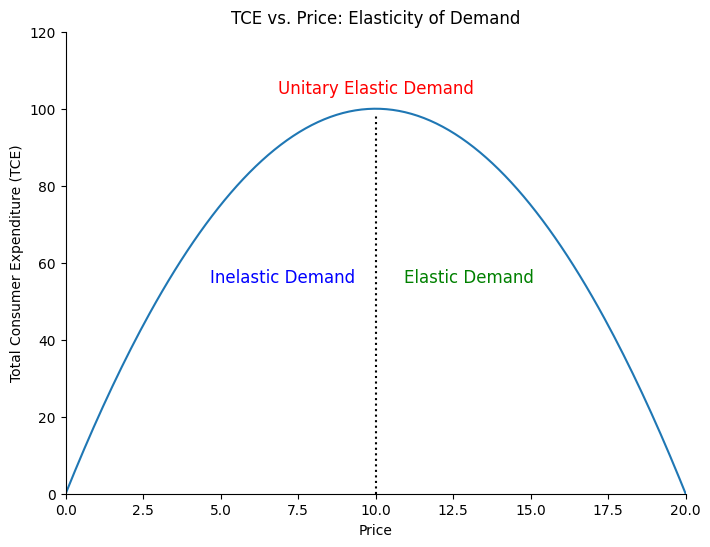

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Generate some sample price points
price = np.linspace(0, 20, 200)
# Parabola: TCE = -a(p - h)^2 + k (vertex at (h,k))
h = 10  # vertex (unitary elasticity)
k = 100
a = k / (h**2)  # so parabola passes through (0,0) and (20,0)
TCE = -a * (price - h)**2 + k

fig, ax = plt.subplots(figsize=(8,6))

# Plot the downward parabola
ax.plot(price, TCE, label='TCE Curve')

# Plot a dotted vertical line at the vertex (unitary point)
ax.axvline(h, 0, 0.82, linestyle=':', color='black')

# Annotate regions
ax.annotate("Inelastic Demand", xy=(7, 55), fontsize=12, ha='center', color='blue')
ax.annotate("Elastic Demand", xy=(13, 55), fontsize=12, ha='center', color='green')
ax.annotate("Unitary Elastic Demand", xy=(h, k+4), fontsize=12, ha='center', color='red')

# Label axes
ax.set_xlabel("Price")
ax.set_ylabel("Total Consumer Expenditure (TCE)")
ax.set_title("TCE vs. Price: Elasticity of Demand")

# Set x/y limits for clarity
ax.set_xlim(0, 20)
ax.set_ylim(0, k+20)

# Remove ticks from top and right
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

**Consumer Surplus** : Amount saved by consumers who would purchase a good at a higher price than market price

## Production Function

A **production function** is a rule that shows how much output can be produced from a given number of inputs
$$ Q = f(S_1, S_2, S_3, ..., S_n) $$

*Types of Resources*:

- **Fixed Resources** : Constant over a particular range of output
- **Variable Resources** : Increase with output

**Average Product** : Output per unit of a particular input
$$ AP = \frac{Q}{S} $$


**Marginal Product** : Additional output produced as an input is increased by one unit
$$ MP = \frac{dQ}{dS} $$


### Slopes of the Product Curve
- Take the slope of the line from origin to a point, that is the AP.
- Take the tangent of the total product curve at a given point and get its slope, that is the MP.

**Point of Inflexion** : Indicates the Maximum MP; MP increases before, and decreases after.

**Point of Tangency** : Indicates the Maximum AP; AP increases before, and decreases after.

After the vertex of the product curve, the MP becomes negative.

**Law of Diminishing Marginal Returns** : Principle that as the use of an input increases with other inputs fixed, the resulting additions to output will eventually decrease.

### How to find the Maximum MP and AP
**AP** : Take the derivative of the AP function and set to 0

**MP** : Take the derivative of the MP function (second derivative of production function) and set to 0

**Isoquants** : Curve showing all possible combinations of inputs that yield the same output

**Isoquant Map** : Graph combining a number of isoqunts, used to describe a production function
- Useful for seeing the diminishing or increasing marginal returns at a fixed amount of capital

### Returns to Scale
- **Returns to Scale** : Rate at which output increases as inputs are increased proportionaly 
- **Increasing Returns to Scale** : Situation in which output more than doubles when all inputs are doubled
- **Constant Returns to Scale** : Situation in which output doubles when all inputs are doubled
- **Decreasing Returns to Scale** : Situation in which output less than doubles when all inputs are doubled

## Production Cost Function

The **production cost function** represents the total cost associated with the production of given levels of output per unit of time.

$$ TC = f(C_1, C_2, C_3, ..., C_n, R) $$ 
where $n$ is the number of costs and $R$ is output

*Types of Cost*
- **Fixed costs** : Constant over a particular range of output
- **Variable costs** : Those that change with output

*Key Characteristics*
- The production cost function shows a decreasing cost of each additional unit prior to the inflexion point, meaning increasing returns to variable input
- The production cost function shows an increasing cost of each additional unit after the inflexion point, meaning decreasing returns to variable input

**Average Cost** : Cost per unit of a particular output
$$ AC = TC / R $$
**Marginal Cost** : Additional cost incurred as an output is increased by one unit
$$ MC = \frac{dTC}{dR} $$

**Point of Inflexion** : Indicates the Minimum MC; MC decreases before, and increases after.

**Point of Tangency** : Indicates the Minimum AC; AC decreases before, and increases after.